In [1]:
import torch
import sklearn
import torch.distributions as D
import numpy as np
from numpy.random import default_rng
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import pymc3 as pm
import arviz as az

from insilico_stimuli.stimuli import GaborSet

seed = 42
rng = default_rng(seed=seed)
torch.manual_seed(seed=seed)
EPSILON = 1e-12
mpl.style.use("seaborn")
az.style.use("arviz-darkgrid")

In [2]:
def plot_samples(trace):
    fig, axs = plt.subplots(nrows=3, ncols=6, dpi=150, sharex=True, sharey=True)
    for idx, ax in enumerate(axs.ravel()):
        sns.histplot(
            trace["neuron"][:, idx].ravel(),
            color="red",
            stat="probability",
            element="step",
            ax=ax,
        )
        ax.text(
            0.7,
            0.6,
            f"{np.mean(trace['neuron'][:, idx].ravel()):.2f}",
            fontsize=6,
            transform=ax.transAxes,
        )
        ax.tick_params(axis="both", which="major", labelsize=5)
        # reduce the font size of the x and y labels
        ax.xaxis.label.set_size(5)
        ax.yaxis.label.set_size(5)

In [3]:
def plot_correlation(trace):
    fig, ax = plt.subplots(dpi=150)
    sns.heatmap(np.corrcoef(trace["neuron"].T), ax=ax, cmap="viridis")
    # make it a square plot
    ax.set_aspect("equal")
    # reduce the tick size
    ax.tick_params(axis="both", which="major", labelsize=9)

# PFs of Neurons in 3x3 grid parameterized stimulus

In [4]:
gabor_data = torch.load("/src/project/computed/gabors_overlapping.pt")
gabors = torch.tensor(gabor_data["gabors"].images()).float()

### Each panel below represents a different neuron's PF

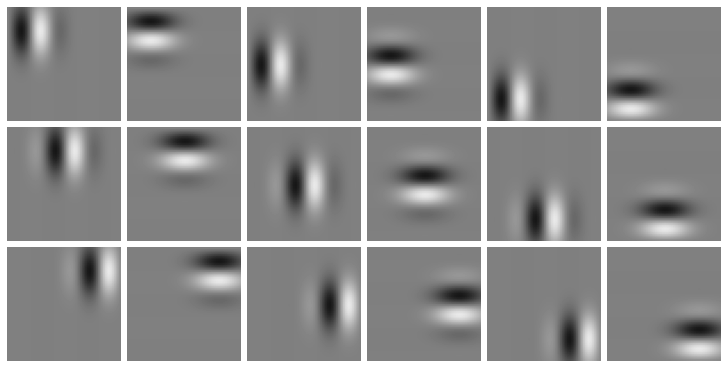

In [5]:
plt.figure(figsize=(10, 5))
for i, img in enumerate(gabor_data["gabors"].images()):
    plt.subplot(3, 6, i + 1)
    plt.imshow(img, cmap="gray", vmin=-1, vmax=1)
    plt.axis("off")

# Defining the probabilistic model and posterior sampling
### Assumes a sampling model where each neuron is a latent variable and encodes the stimulus using its PF as above. The image generative model is assumed to be linear likelihood with Gaussian conditional. The prior distribution (distribution over neuronal responses) is assumed to be exponential

In [6]:
def sample_posterior(stimulus):
    z_dim = 18
    Lambda = torch.ones(z_dim)
    sigma = torch.abs(torch.rand(1)) + EPSILON
    model = pm.Model()
    with model:
        z = pm.Exponential("neuron", lam=Lambda, shape=z_dim)
        x = pm.Normal(
            "stimulus", mu=(gabors.permute(1, 2, 0) @ z), sigma=sigma, observed=stimulus
        )
        trace = pm.sample(1_000, return_inferencedata=False)
    return trace

# Presenting a center only gabor stimulus

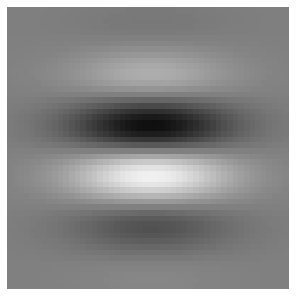

In [7]:
gabor_params_center = {
    "canvas_size": [50, 50],
    "sizes": [40],
    "spatial_frequencies": [1 / 20],
    "contrasts": [1.0],
    "grey_levels": [0.0],
    "eccentricities": [0.0],
    "locations": [[25, 25]],
    "orientations": [np.pi / 2],
    "phases": [np.pi / 2],
    "relative_sf": False,
}

gabor_set_center = GaborSet(**gabor_params_center)
stimuli = torch.tensor(gabor_set_center.images()).float().sum(dim=0)
im = plt.imshow(stimuli, cmap="gray", vmin=-1, vmax=1)
ax = plt.axis("off")

### Get posterior and sample in order to look at neuronal response distributions

In [8]:
trace = sample_posterior(stimuli)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [neuron]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 44 seconds.
The number of effective samples is smaller than 25% for some parameters.


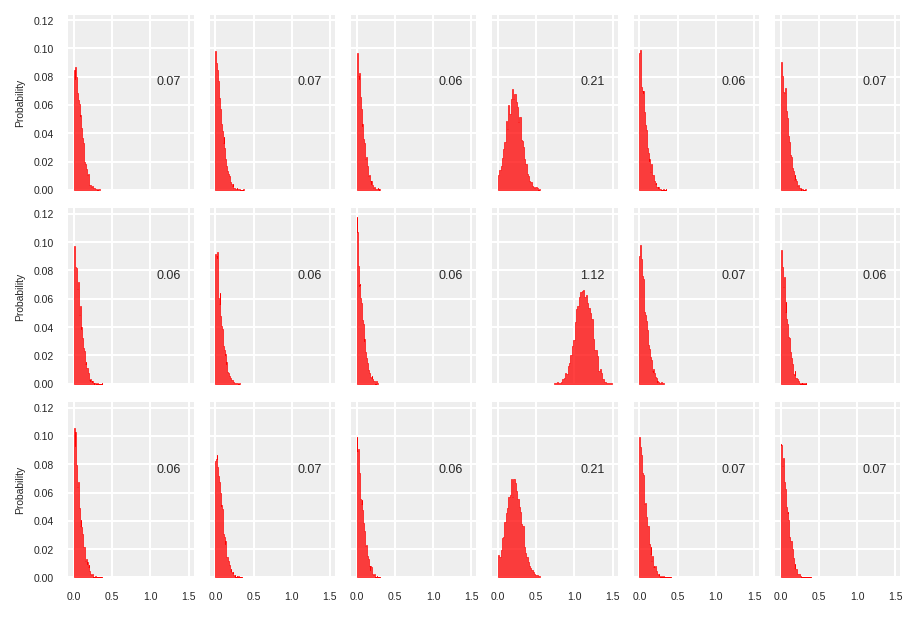

In [9]:
plot_samples(trace)

### Compute the correlation of the posterior

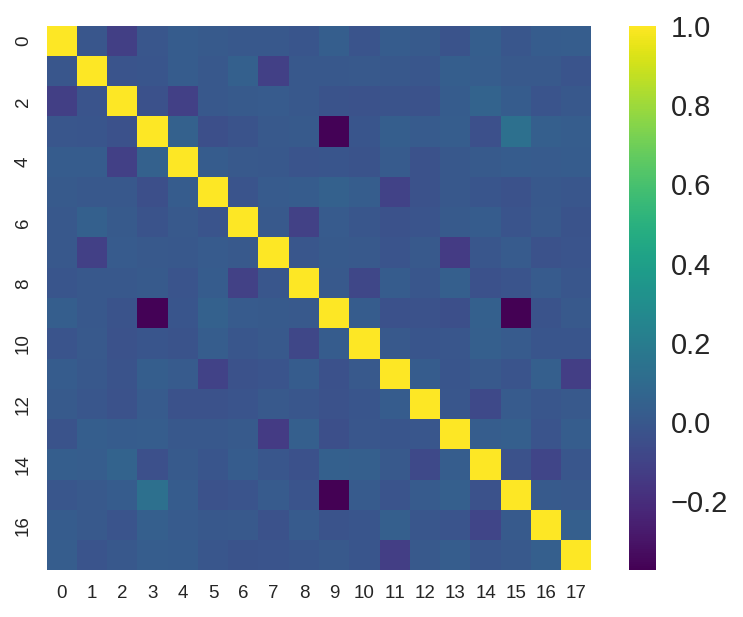

In [10]:
plot_correlation(trace)

# Now present a spatially completing surround pattern

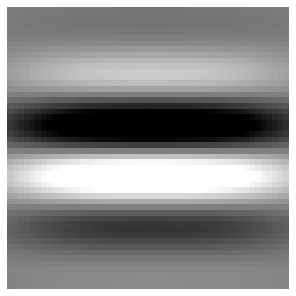

In [11]:
gabor_params_completing = {
    "canvas_size": [50, 50],
    "sizes": [40],
    "spatial_frequencies": [1 / 20],
    "contrasts": [1.0],
    "grey_levels": [0.0],
    "eccentricities": [0.0],
    "locations": [[10, 25], [25, 25], [40, 25]],
    "orientations": [np.pi / 2],
    "phases": [np.pi / 2],
    "relative_sf": False,
}

gabor_set_completing = GaborSet(**gabor_params_completing)
completing_stimulus = torch.tensor(gabor_set_completing.images()).float().sum(dim=0)
im = plt.imshow(completing_stimulus, cmap="gray", vmin=-1, vmax=1)
ax = plt.axis("off")

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [neuron]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 61 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


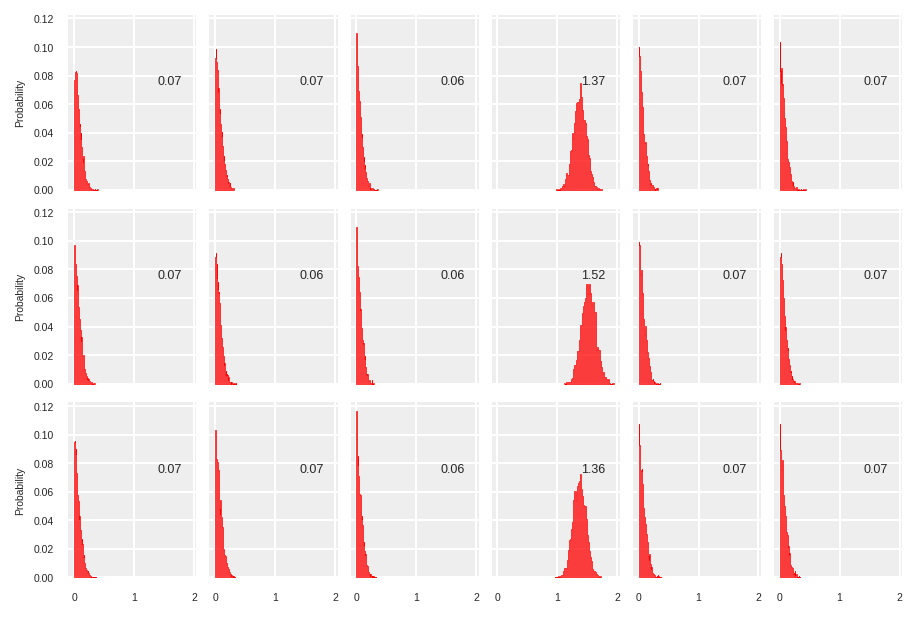

In [12]:
trace_completing = sample_posterior(completing_stimulus)
plot_samples(trace_completing)

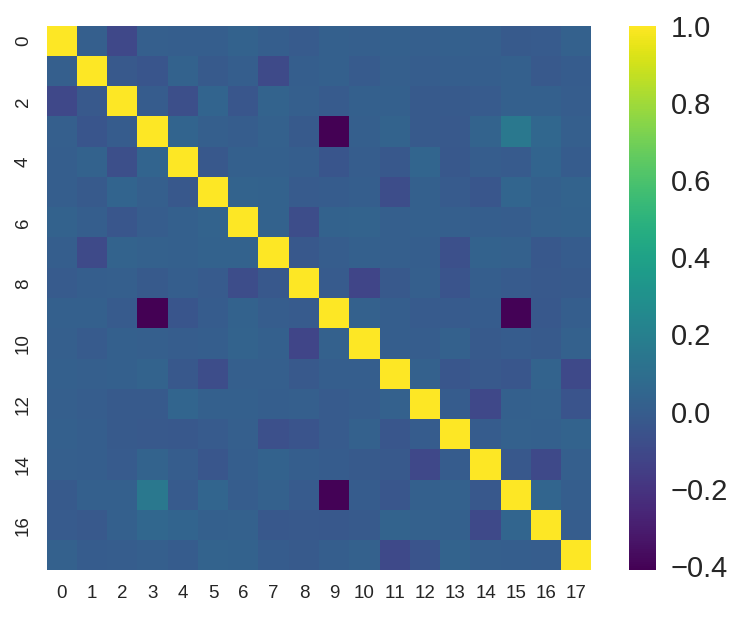

In [13]:
plot_correlation(trace_completing)

# Reduce the contrast of the center surround stimulus

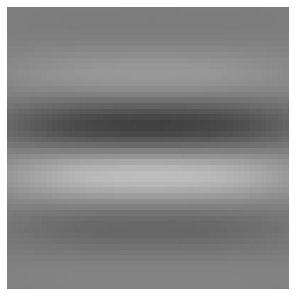

In [25]:
gabor_params_completing_light = {
    "canvas_size": [50, 50],
    "sizes": [40],
    "spatial_frequencies": [1 / 20],
    "contrasts": [0.33],
    "grey_levels": [0.0],
    "eccentricities": [0.0],
    "locations": [[10, 25], [25, 25], [40, 25]],
    "orientations": [np.pi / 2],
    "phases": [np.pi / 2],
    "relative_sf": False,
}

gabor_set_completing_light = GaborSet(**gabor_params_completing_light)
completing_stimulus_light = (
    torch.tensor(gabor_set_completing_light.images()).float().sum(dim=0)
)
im = plt.imshow(completing_stimulus_light, cmap="gray", vmin=-1, vmax=1)
ax = plt.axis("off")

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [neuron]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 30 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


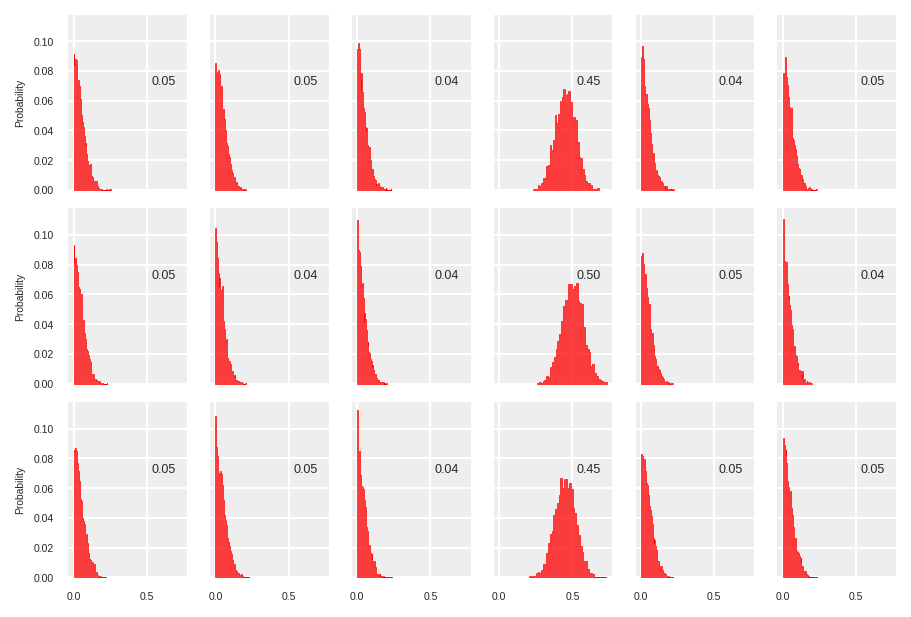

In [31]:
trace_completing_light = sample_posterior(completing_stimulus_light)
plot_samples(trace_completing_light)

# Increaes the contrast of the center surround stimulus a bit more

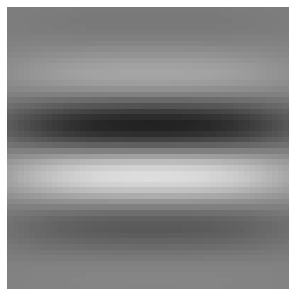

In [29]:
gabor_params_completing_light_plus = {
    "canvas_size": [50, 50],
    "sizes": [40],
    "spatial_frequencies": [1 / 20],
    "contrasts": [0.5],
    "grey_levels": [0.0],
    "eccentricities": [0.0],
    "locations": [[10, 25], [25, 25], [40, 25]],
    "orientations": [np.pi / 2],
    "phases": [np.pi / 2],
    "relative_sf": False,
}

gabor_set_completing_light_plus = GaborSet(**gabor_params_completing_light_plus)
completing_stimulus_light_plus = (
    torch.tensor(gabor_set_completing_light_plus.images()).float().sum(dim=0)
)
im = plt.imshow(completing_stimulus_light_plus, cmap="gray", vmin=-1, vmax=1)
ax = plt.axis("off")

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [neuron]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 31 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


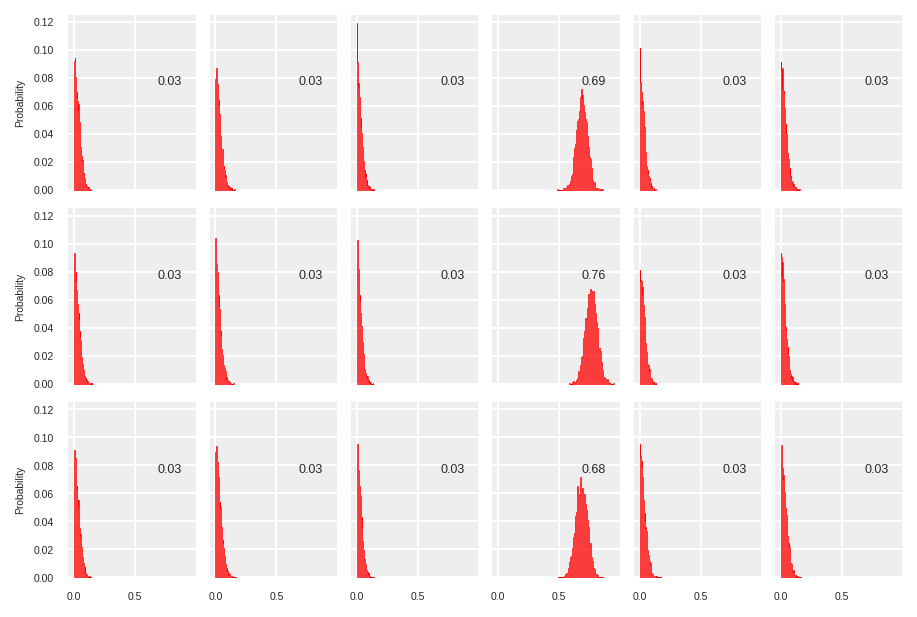

In [30]:
trace_completing_light_plus = sample_posterior(completing_stimulus_light_plus)
plot_samples(trace_completing_light_plus)

# Now present a spatially incongruent surround pattern

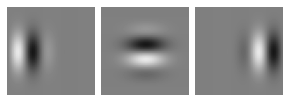

In [14]:
gabor_params_incongruent = {
    "canvas_size": [50, 50],
    "sizes": [30],
    "spatial_frequencies": [1 / 20],
    "contrasts": [1.0],
    "grey_levels": [0.0],
    "eccentricities": [0.0],
    "locations": [[10, 25], [25, 25], [40, 25]],
    "orientations": [np.pi / 2, 0],
    "phases": [np.pi / 2],
    "relative_sf": False,
}

gabor_set_incongruent = GaborSet(**gabor_params_incongruent)
stimuli_incongruent = (
    torch.tensor(gabor_set_incongruent.images()).float()[[1, 2, 5]].sum(dim=0)
)

plt.figure(figsize=(10, 5))
for i, img in enumerate(gabor_set_incongruent.images()[[1, 2, 5]]):
    plt.subplot(4, 8, i + 1)
    plt.imshow(img, cmap="gray", vmin=-1, vmax=1)
    plt.axis("off")

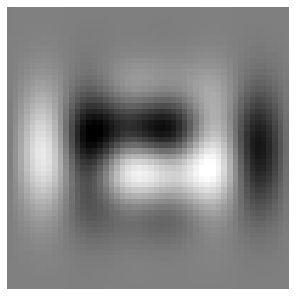

In [15]:
im = plt.imshow(stimuli_incongruent, cmap="gray", vmin=-1, vmax=1)
ax = plt.axis("off")

In [16]:
trace_incongruent = sample_posterior(stimuli_incongruent)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [neuron]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 45 seconds.


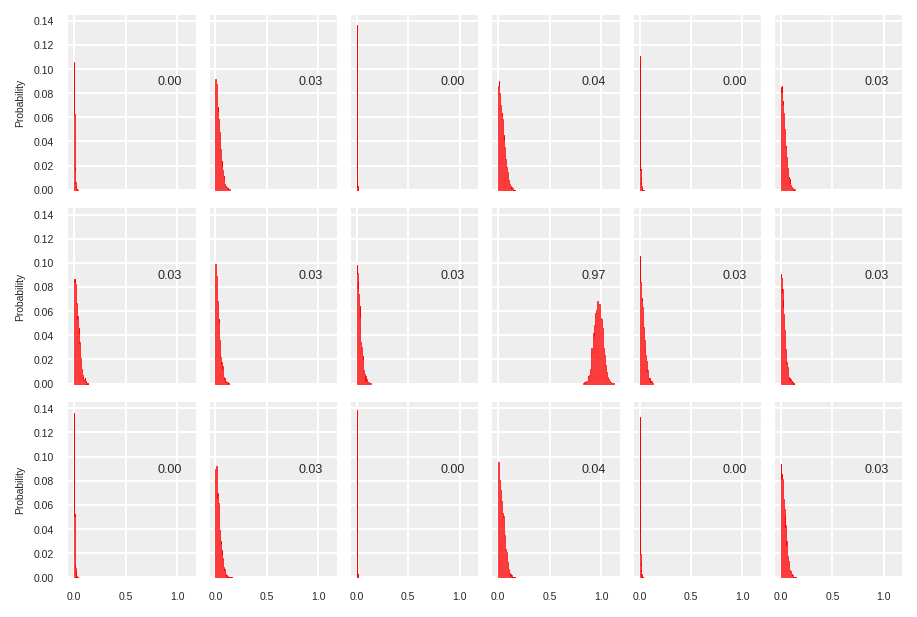

In [17]:
plot_samples(trace_incongruent)

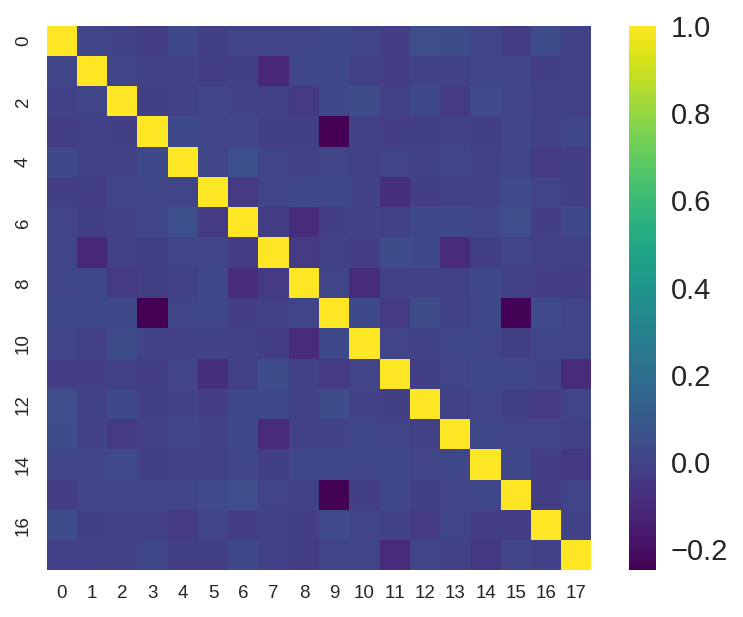

In [18]:
plot_correlation(trace_incongruent)

# Summarizing the effect of surrounds

In [ ]:
trace, trace_completing, trace_incongruent

/usr/local/lib/python3.8/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.8/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.8/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `kdeplot` (an axe

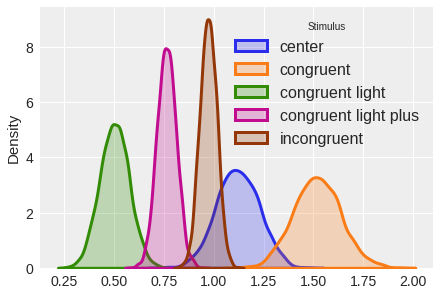

In [36]:
center_samples = trace["neuron"][:, 9].ravel()
completing_samples = trace_completing["neuron"][:, 9].ravel()
completing_samples_light = trace_completing_light["neuron"][:, 9].ravel()
completing_samples_light_plus = trace_completing_light_plus["neuron"][:, 9].ravel()
incongruent_samples = trace_incongruent["neuron"][:, 9].ravel()
# plot a seaborn histogram these samples on the same plot and color them differently, also label them
sns.distplot(
    center_samples,
    hist=False,
    kde=True,
    kde_kws={"shade": True, "linewidth": 3},
    label="center",
)
sns.distplot(
    completing_samples,
    hist=False,
    kde=True,
    kde_kws={"shade": True, "linewidth": 3},
    label="congruent",
)
sns.distplot(
    completing_samples_light,
    hist=False,
    kde=True,
    kde_kws={"shade": True, "linewidth": 3},
    label="congruent light",
)
sns.distplot(
    completing_samples_light_plus,
    hist=False,
    kde=True,
    kde_kws={"shade": True, "linewidth": 3},
    label="congruent light plus",
)
sns.distplot(
    incongruent_samples,
    hist=False,
    kde=True,
    kde_kws={"shade": True, "linewidth": 3},
    label="incongruent",
)
plt.legend(prop={"size": 16}, title="Stimulus")